In [1]:
# Steps
#0. Preprocess + EDA + Feature Selection
#1. Extract input and output cols
#2. Scale the values I
#3. Train test split
#4. Train the model
#5. Evaluate the model/model selection
#6. Deploy the model

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('D:/ML/placement.csv')

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,attendance,placement
0,0,6.5,110,0.70,1
1,1,7.5,90,0.80,1
2,2,7.8,120,0.85,1
3,3,5.5,140,0.50,0
4,4,4.0,120,0.70,0


In [5]:
df.shape

(51, 5)

In [6]:
import matplotlib.pyplot as plt

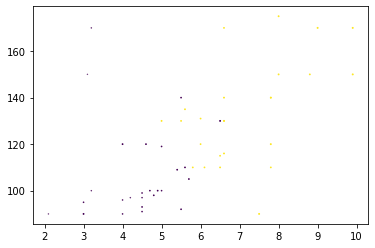

In [7]:
plt.scatter(df['cgpa'],df['iq'],df['attendance'],c=df['placement'])

In [8]:
X = df.iloc[:, 0:2]
Y = df.iloc[:, -1]

In [9]:
X

,Unnamed: 0,cgpa
0,0,6.5
1,1,7.5
2,2,7.8
3,3,5.5
4,4,4.0
5,5,6.6
6,6,3.0
7,7,3.0
8,8,4.0
9,9,7.8


In [10]:
Y

0     1
1     1
2     1
3     0
4     0
5     1
6     0
7     0
8     0
9     1
10    1
11    0
12    1
13    1
14    1
15    0
16    0
17    0
18    0
19    1
20    1
21    1
22    1
23    1
24    0
25    0
26    0
27    0
28    0
29    1
30    1
31    1
32    1
33    1
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    1
42    1
43    1
44    1
45    1
46    0
47    0
48    0
49    0
50    1
Name: placement, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.1)

In [12]:
X_train

,Unnamed: 0,cgpa
45,45,9.9
25,25,4.7
35,35,5.6
47,47,3.2
39,39,3.2
28,28,4.6
37,37,6.5
18,18,4.5
32,32,6.5
42,42,5.6


In [13]:
X_test

,Unnamed: 0,cgpa
20,20,6.6
38,38,4.2
15,15,4.0
49,49,5.0
44,44,8.8
3,3,5.5


In [14]:
Y_train

45    1
25    0
35    0
47    0
39    0
28    0
37    0
18    0
32    1
42    1
46    0
17    0
4     0
50    1
10    1
19    1
41    1
43    1
36    0
5     1
14    1
16    0
11    0
26    0
31    1
40    0
12    1
0     1
27    0
33    1
22    1
30    1
34    0
9     1
21    1
29    1
6     0
23    1
1     1
48    0
2     1
8     0
24    0
13    1
7     0
Name: placement, dtype: int64

In [15]:
Y_test

20    1
38    0
15    0
49    0
44    1
3     0
Name: placement, dtype: int64

In [16]:
#Scaling
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

In [18]:
X_train = scaler.fit_transform(X_train)

In [19]:
X_train

array([[ 1.41853084,  2.29726005],
       [ 0.02932762, -0.58818736],
       [ 0.72392923, -0.088783  ],
       [ 1.55745117, -1.42052795],
       [ 1.00176988, -1.42052795],
       [ 0.23770811, -0.64367673],
       [ 0.86284956,  0.41062136],
       [-0.4568935 , -0.6991661 ],
       [ 0.51554875,  0.41062136],
       [ 1.21015036, -0.088783  ],
       [ 1.48799101, -2.03091106],
       [-0.52635366, -0.14427237],
       [-1.42933576, -0.97661297],
       [ 1.76583165,  0.1331745 ],
       [-1.01257479, -0.42171924],
       [-0.38743334,  0.02219575],
       [ 1.1406902 ,  1.13198321],
       [ 1.27961052,  0.46611073],
       [ 0.7933894 , -0.03329362],
       [-1.3598756 ,  0.46611073],
       [-0.73473415,  1.24296196],
       [-0.59581383, -0.6991661 ],
       [-0.94311463, -0.42171924],
       [ 0.09878778, -0.53269798],
       [ 0.44608859,  0.18866387],
       [ 1.07123004, -1.47601733],
       [-0.87365447,  1.24296196],
       [-1.7071764 ,  0.41062136],
       [ 0.16824795,

In [20]:
X_test = scaler.transform(X_test)

In [21]:
X_test

array([[-0.31797318,  0.46611073],
       [ 0.93230972, -0.86563422],
       [-0.66527399, -0.97661297],
       [ 1.69637149, -0.42171924],
       [ 1.34907068,  1.68687694],
       [-1.49879592, -0.14427237]])

In [22]:
#logistic regression classifier
from sklearn.linear_model import LogisticRegression

In [23]:
clf = LogisticRegression()

In [24]:
#model training
clf.fit(X_train, Y_train)

LogisticRegression()

In [25]:
#Evaluate the model
Y_pred = clf.predict(X_test)

In [26]:
Y_test

20    1
38    0
15    0
49    0
44    1
3     0
Name: placement, dtype: int64

In [27]:
from sklearn.metrics import accuracy_score

In [28]:
accuracy_score(Y_test, Y_pred)

0.8333333333333334

In [29]:
%pip install mlxtend==0.23.1

Note: you may need to restart the kernel to use updated packages.


In [31]:
from mlxtend.plotting import plot_decision_regions

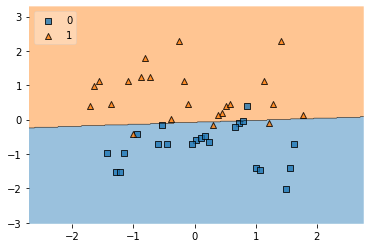

In [33]:
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)